In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers, Sequential

import matplotlib.pyplot as plt
import numpy as np
#from sklearn.utils import 
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
source_dir = "/kaggle/input/datasets/geadalfa/cracked-non-cracked-surface-datasets/Bangunan Retak"
dest_dir = "/kaggle/working/NewDataset"

In [4]:
#pip install split-folders

In [5]:
#import splitfolders
#splitfolders.ratio(source_dir, output=dest_dir, ratio=(.8, .15, .05), group_prefix=None, move=False)

In [6]:
batch_size = 64
image_size = (224, 224)

train = keras.preprocessing.image_dataset_from_directory(dest_dir + '/train', label_mode = "categorical", batch_size = batch_size, image_size = image_size, )
val = keras.preprocessing.image_dataset_from_directory(dest_dir + '/val', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )
test = keras.preprocessing.image_dataset_from_directory(dest_dir + '/test', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )

Found 76873 files belonging to 2 classes.
Found 14413 files belonging to 2 classes.
Found 4806 files belonging to 2 classes.


Performance Optimization: Prefetch

In [7]:
train_copy = train
test_copy = test
train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)
test = test.prefetch(buffer_size=tf.data.AUTOTUNE)

In [8]:
import os
import numpy as np
from sklearn.utils import class_weight

# 1. Define the path to your training folder 
# (This should match what you used in image_dataset_from_directory)
train_dir = dest_dir + '/train'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(train_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_train_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_train_simulated.extend([i] * num_images)

y_train_simulated = np.array(y_train_simulated)

# 4. Compute the class weights using sklearn
class_labels = np.unique(y_train_simulated)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train_simulated
)

# 5. Format into the dictionary Keras expects
class_weights = dict(zip(class_labels, class_weights_array))

# Display the results
class_indices = {class_names[i]: i for i in range(len(class_names))}
print(f"Class indices: {class_indices}")
print(f"Calculated weights: {class_weights}")

Class indices: {'Cracked': 0, 'Non Cracked': 1}
Calculated weights: {np.int64(0): np.float64(1.6867731601351648), np.int64(1): np.float64(0.7106552527456274)}


In [9]:
!pip install optuna
!pip install optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 4.0 MB/s eta 0:00:00


In [10]:
import optuna
from optuna.integration import TFKerasPruningCallback
from keras import layers, regularizers

# Take 200 batches for training and 50 batches for validation.
tune_train = train.take(200)

def objective(trial):
    # 1. Clear session to avoid cluttering GPU memory
    tf.keras.backend.clear_session()
    
    # --- 2. Suggest Hyperparameters for RNN ---
    lstm_units = trial.suggest_categorical("lstm_units", [32, 64, 128])
    dense_units = trial.suggest_int("dense_units", 128, 512, step=128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    # --- 3. Build Simulated MDRNN Model Dynamically ---
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Downsample to 56x56 to make the sequence length manageable for the LSTM
    # This turns the image into 56 time steps of size (56 * 3)
    x = layers.AveragePooling2D((4, 4))(inputs)
    
    # === MDRNN 4-DIRECTIONAL SCANNERS ===
    
    # PATH A: Horizontal Scanners (Top-to-Bottom & Bottom-to-Top)
    # Shape becomes: (batch_size, 56 time_steps, 168 features)
    x_rows = layers.Reshape((56, 56 * 3))(x)
    lstm_rows = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False)
    )(x_rows)
    
    # PATH B: Vertical Scanners (Left-to-Right & Right-to-Left)
    # Permute transposes the image: (batch, width, height, channels)
    x_cols = layers.Permute((2, 1, 3))(x)
    x_cols = layers.Reshape((56, 56 * 3))(x_cols)
    lstm_cols = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False)
    )(x_cols)
    
    # Combine the hidden memory states of all 4 directions
    merged_state = layers.Concatenate()([lstm_rows, lstm_cols])
    
    # === Classification Head ===
    x_head = layers.BatchNormalization()(merged_state)
    x_head = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x_head)
    x_head = layers.Dropout(dropout_rate)(x_head)
    outputs = layers.Dense(2, activation="softmax")(x_head)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # --- 4. Compile Model ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # --- 5. Callbacks & Training ---
    callbacks = [
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
    ]
    
    history = model.fit(
        tune_train, 
        validation_data=val,
        epochs=15,       
        callbacks=callbacks,
        class_weight=class_weights,
    )
    
    return max(history.history["val_accuracy"])

# Run the study
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20) 

print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

[I 2026-05-08 11:49:38,268] A new study created in memory with name: no-name-8803a3bf-7f86-4de8-acd2-9a23b3968e1c


Epoch 1/15


I0000 00:00:1778240982.529408     101 cuda_dnn.cc:529] Loaded cuDNN version 91002


200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.7040 - loss: 0.5943 - val_accuracy: 0.2965 - val_loss: 1.4775
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.7865 - loss: 0.5441 - val_accuracy: 0.7821 - val_loss: 0.6277
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8287 - loss: 0.5146 - val_accuracy: 0.2984 - val_loss: 1.0787
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8306 - loss: 0.5216 - val_accuracy: 0.8350 - val_loss: 0.4790
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8324 - loss: 0.5211 - val_accuracy: 0.8252 - val_loss: 0.4837
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8282 - loss: 0.5335 - val_accuracy: 0.2992 - val_loss: 1.4238
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8355 - loss: 0.5140 - val_accuracy: 0.2990 - val_loss: 1.5745


[I 2026-05-08 11:51:08,127] Trial 0 finished with value: 0.8350100517272949 and parameters: {'lstm_units': 64, 'dense_units': 128, 'dropout_rate': 0.3910224772598314, 'lr': 0.0006607662342028952}. Best is trial 0 with value: 0.8350100517272949.


...

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6410 - loss: 0.7345 - val_accuracy: 0.7962 - val_loss: 0.5439
Epoch 2/15
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7755 - loss: 0.5465

[I 2026-05-08 12:12:51,435] Trial 18 pruned. Trial was pruned at epoch 1.


Epoch 1/15
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5583 - loss: 0.6850

[I 2026-05-08 12:13:08,217] Trial 19 pruned. Trial was pruned at epoch 0.


Best trial: 0.8642197847366333
Best params: {'lstm_units': 128, 'dense_units': 512, 'dropout_rate': 0.2620196738906133, 'lr': 6.621369145869814e-05}


In [11]:
print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

Best trial: 0.8642197847366333
Best params: {'lstm_units': 128, 'dense_units': 512, 'dropout_rate': 0.2620196738906133, 'lr': 6.621369145869814e-05}


In [13]:
# --- 1. Parse the Best Parameters Automatically ---
# study.best_params is a dictionary containing the winning values
best_params = study.best_params

print("Training final model with parameters:", best_params)

# --- 2. Re-instantiate Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

# --- 3. Build Final Model Dynamically using Parsed Variables ---
inputs = tf.keras.layers.Input(shape=(224, 224, 3))

# Connect data augmentation to the inputs!
x = data_augmentation(inputs)

# Downsample to 56x56 to make the sequence length manageable for the LSTM
x = layers.AveragePooling2D((4, 4))(x)

# PATH A: Horizontal Scanners (Top-to-Bottom & Bottom-to-Top)
x_rows = layers.Reshape((56, 56 * 3))(x)
lstm_rows = layers.Bidirectional(
    # Inject parsed 'lstm_units' here
    layers.LSTM(best_params['lstm_units'], return_sequences=False)
)(x_rows)

# PATH B: Vertical Scanners (Left-to-Right & Right-to-Left)
x_cols = layers.Permute((2, 1, 3))(x)
x_cols = layers.Reshape((56, 56 * 3))(x_cols)
lstm_cols = layers.Bidirectional(
    # Inject parsed 'lstm_units' here
    layers.LSTM(best_params['lstm_units'], return_sequences=False)
)(x_cols)

# Combine the hidden memory states of all 4 directions
merged_state = layers.Concatenate()([lstm_rows, lstm_cols])

# === Classification Head ===
x_head = layers.BatchNormalization()(merged_state)

# Inject parsed 'dense_units' here
x_head = layers.Dense(best_params['dense_units'], activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x_head)

# Inject parsed 'dropout_rate' here
x_head = layers.Dropout(best_params['dropout_rate'])(x_head)
outputs = layers.Dense(2, activation="softmax")(x_head)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

# --- 4. Compile using the parsed 'lr' ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Final Callbacks ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_crack_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode="min")
]

# --- 6. Train on the FULL Dataset ---
history = model.fit(
    train,               
    validation_data=val,
    epochs=100,           
    callbacks=callbacks,
    class_weight=class_weights
)

Training final model with parameters: {'lstm_units': 128, 'dense_units': 512, 'dropout_rate': 0.2620196738906133, 'lr': 6.621369145869814e-05}
Epoch 1/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 51s 38ms/step - accuracy: 0.7938 - loss: 0.4922 - val_accuracy: 0.3087 - val_loss: 2.2644 - learning_rate: 6.6214e-05
Epoch 2/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 46s 38ms/step - accuracy: 0.8454 - loss: 0.4171 - val_accuracy: 0.4163 - val_loss: 1.0400 - learning_rate: 6.6214e-05
Epoch 3/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.8484 - loss: 0.4051 - val_accuracy: 0.3864 - val_loss: 1.1032 - learning_rate: 6.6214e-05
Epoch 4/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 46s 38ms/step - accuracy: 0.8512 - loss: 0.3951 - val_accuracy: 0.8294 - val_loss: 0.3894 - learning_rate: 6.6214e-05
Epoch 5/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.8544 - loss: 0.3901 - val_accuracy: 0.6461 - val_loss: 0.5833 - learning_rate: 6.6214e-05
Epoch 6/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 46s 38ms/

In [14]:
#loss, accuracy, precision, recall
print(model.evaluate(test))

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8510 - loss: 0.3130
[0.31042736768722534, 0.882438600063324]


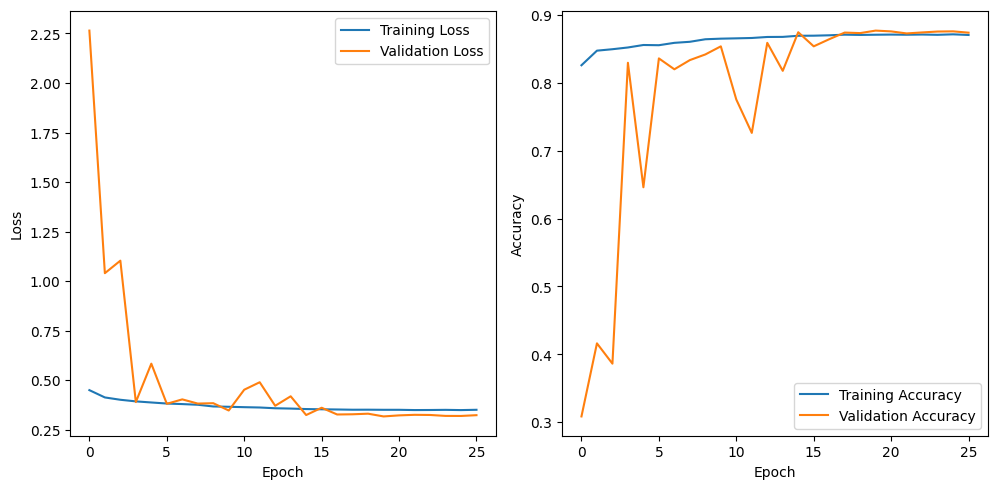

In [15]:
plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
test_dir = dest_dir + '/test'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(test_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_test_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_test_simulated.extend([i] * num_images)

y_true = np.array(y_test_simulated)



# Use the model to predict the classes
y_pred = np.argmax(model.predict(test), axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


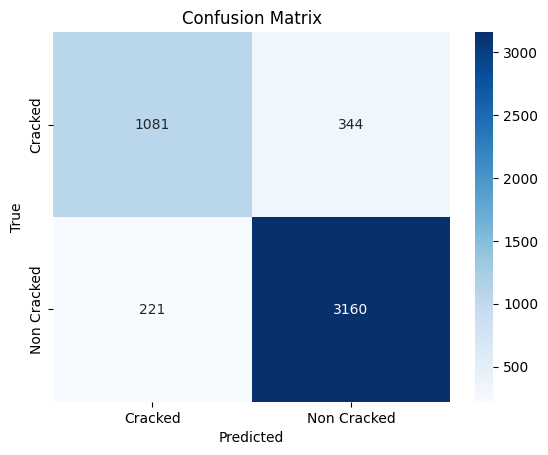

[[1081  344]
 [ 221 3160]]


In [17]:
import seaborn as sns

# Compute and print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_copy.class_names, yticklabels=test_copy.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(conf_matrix)

In [3]:
Model = keras.models.load_model("best_MDRNN_model.keras")
Model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 56, 56, 3) │          0 │ data_augmentatio… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 56, 56, 3) │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 56, 168)   │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 56, 168)   │          0 │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 256)       │    304,128 │ reshape_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 256)       │    304,128 │ reshape_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │      1,026 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,912 (9.99 MB)

 Trainable params: 872,962 (3.33 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 1,745,926 (6.66 MB)